In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_work = pd.read_csv('/content/new_df.csv')

In [ ]:
BASE_FEATURES = [
    "log_duration",
    "log_bytes_rate",
    "payload_bytes_mean",
    "payload_bytes_std",
    "payload_bytes_skewness",
    "log_down_up_rate",
]

In [ ]:
benign_df = df_work[df_work["label"] == "Benign"].copy()

baseline_benign, benign_remaining = train_test_split(
    benign_df,
    test_size=0.65,
    random_state=42
)

print(benign_remaining.shape)

(41165, 7)


In [ ]:
baseline_median = baseline_benign[BASE_FEATURES].median()

baseline_iqr = (
    baseline_benign[BASE_FEATURES].quantile(0.75)
    - baseline_benign[BASE_FEATURES].quantile(0.25)
)

baseline_iqr = baseline_iqr.replace(0, 1e-6)

baseline_iqr

,0
log_duration,1.330406
log_bytes_rate,1.750174
payload_bytes_mean,106.900300
payload_bytes_std,275.889600
payload_bytes_skewness,0.479800
log_down_up_rate,0.087011


In [ ]:
balanced_parts = []

min_class_size = min(
    len(benign_remaining),
    *[
        len(df_work[df_work["label"] == cls])
        for cls in ["Attack", "Suspicious"]
    ]
)

balanced_parts.append(
    benign_remaining.sample(min_class_size, random_state=42)
)

for cls in ["Attack", "Suspicious"]:
    balanced_parts.append(
        df_work[df_work["label"] == cls]
        .sample(min_class_size, random_state=42)
    )

df_balanced = (
    pd.concat(balanced_parts)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(df_balanced["label"].value_counts())

label
Suspicious    7679
Benign        7679
Attack        7679
Name: count, dtype: int64


In [ ]:
deviation_df = pd.DataFrame(index=df_balanced.index)

for feature in BASE_FEATURES:

    deviation_df[f"{feature}_dev"] = (
        (df_balanced[feature] - baseline_median[feature]).abs()
        / baseline_iqr[feature]
    )

# Aggregated anomaly metrics

deviation_df["mean_deviation"] = deviation_df.mean(axis=1)

deviation_df["max_deviation"] = deviation_df.max(axis=1)

deviation_df["std_deviation"] = deviation_df.std(axis=1)

deviation_df["sum_deviation"] = deviation_df.sum(axis=1)

X = deviation_df
y = df_balanced["label"]

print(X.head())

   log_duration_dev  log_bytes_rate_dev  payload_bytes_mean_dev  \
0          1.174562            1.320892                0.272387   
1          1.244890            1.743231                0.601665   
2          1.228910            1.922166                0.025843   
3          0.056749            0.292561                0.278623   
4          2.592635            1.626383                0.826568   

   payload_bytes_std_dev  payload_bytes_skewness_dev  log_down_up_rate_dev  \
0               0.351464                    0.230096              0.084818   
1               0.252068                    1.523760              1.907626   
2               0.155044                    0.973531              0.553975   
3               0.357800                    0.298875              0.084818   
4               0.757015                    1.141100              0.656907   

   mean_deviation  max_deviation  std_deviation  sum_deviation  
0        0.572370       1.320892       0.521922       5.849402 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [ ]:
rf_dev_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_dev_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=3, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [ ]:
y_pred = rf_dev_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8190972222222223
Macro F1: 0.8131960283865807

Classification report:

              precision    recall  f1-score   support

      Attack       0.73      0.91      0.81      1920
      Benign       0.87      0.94      0.90      1920
  Suspicious       0.91      0.60      0.73      1920

    accuracy                           0.82      5760
   macro avg       0.84      0.82      0.81      5760
weighted avg       0.84      0.82      0.81      5760



In [ ]:
cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=rf_dev_model.classes_,
    columns=rf_dev_model.classes_
)

cm

,Attack,Benign,Suspicious
Attack,1755,133,32
Benign,35,1802,83
Suspicious,622,137,1161


In [ ]:
import joblib

joblib.dump(rf_dev_model, "rf_deviation_model.pkl")

joblib.dump(
    {
        "median": baseline_median,
        "iqr": baseline_iqr,
        "features": BASE_FEATURES,
    },
    "rf_deviation_baseline.pkl"
)

['rf_deviation_baseline.pkl']

payload_bytes_mean_dev        0.182710
payload_bytes_std_dev         0.151301
log_duration_dev              0.117237
log_bytes_rate_dev            0.113404
sum_deviation                 0.100914
mean_deviation                0.091970
std_deviation                 0.072657
payload_bytes_skewness_dev    0.071649
max_deviation                 0.064792
log_down_up_rate_dev          0.033365
dtype: float64


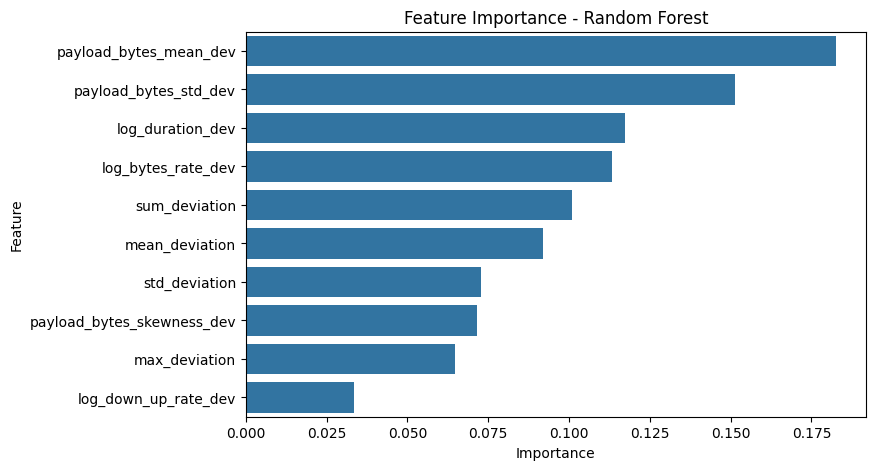

In [ ]:
feature_importance = pd.Series(
    rf_dev_model.feature_importances_,
    index=deviation_df.columns,
).sort_values(ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()